In [ ]:

!pip install -q google-generativeai==0.3.2
!pip install -q langchain==0.1.0
!pip install -q langchain-google-genai==0.0.6
!pip install -q chromadb==0.4.22
!pip install -q pillow==10.1.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.0/798.0 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.2/241.2 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.4/55.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-classic 1.0.0 requires langchain-core<2.0.0,>=1.0.0, but you have langchain-core 0.1.23 which is incompatible.
langchain-classic 1.0.0 requires langsmith<1.0.0,>=0.1.17, but you have langsmith 0.0.87 which is incompatible.
langchain-text-splitters 1.0.0 require

In [ ]:

import os
import google.generativeai as genai
from PIL import Image
import io
from pathlib import Path
from langchain_google_genai import GoogleGenerativeAI
from langchain.prompts import PromptTemplate
from google.colab import files
import base64

# Set your Gemini API key
GEMINI_API_KEY = ""
os.environ["GOOGLE_API_KEY"] = GEMINI_API_KEY
genai.configure(api_key=GEMINI_API_KEY)

print("Libraries imported and API key configured successfully!")



/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_config.py:373: UserWarning: Valid config keys have changed in V2:
* 'allow_population_by_field_name' has been renamed to 'validate_by_name'
  warnings.warn(message, UserWarning)


PydanticUserError: The `__modify_schema__` method is not supported in Pydantic v2. Use `__get_pydantic_json_schema__` instead in class `SecretStr`.

For further information visit https://errors.pydantic.dev/2.11/u/custom-json-schema

In [ ]:
from google.colab import files
import zipfile
import os

print("Please upload your images folder as a ZIP file")
print("   (Right-click your folder → Compress → Upload the .zip file)")
print("\n")

# Upload the zip file
uploaded = files.upload()

# Extract the zip file
for filename in uploaded.keys():
    print(f" Extracting {filename}...")
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall('images_folder')
    print(f" Extracted successfully!")

# Verify uploaded files
image_folder = 'images_folder'
image_files = []
for root, dirs, filenames in os.walk(image_folder):
    for filename in filenames:
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            image_files.append(os.path.join(root, filename))

print(f"\n Found {len(image_files)} images:")
for img in image_files[:10]:  # Show first 10
    print(f"   • {img}")
if len(image_files) > 10:
    print(f"   ... and {len(image_files) - 10} more")

Please upload your images folder as a ZIP file
   (Right-click your folder → Compress → Upload the .zip file)




Saving animal_image.zip to animal_image.zip
 Extracting animal_image.zip...
 Extracted successfully!

 Found 13 images:
   • images_folder/animal_image/elephant.jpg
   • images_folder/animal_image/cat101.jpeg
   • images_folder/animal_image/dog101.jpeg
   • images_folder/animal_image/cat105.jpeg
   • images_folder/animal_image/cat102.jpeg
   • images_folder/animal_image/cat103.jpeg
   • images_folder/animal_image/cat104.jpeg
   • images_folder/animal_image/dog103.jpg
   • images_folder/animal_image/tiger.jpeg
   • images_folder/animal_image/lion.jpeg
   ... and 3 more


In [ ]:
from PIL import Image
import os

# Create a structured database of images
image_database = {}

print(" Processing images and extracting metadata...\n")

for img_path in image_files:
    # Get filename without extension
    filename = os.path.basename(img_path)
    name_without_ext = os.path.splitext(filename)[0]

    # Extract category from filename (e.g., 'cat', 'dog', 'lion')
    # Assumes filenames like 'cat1.jpg', 'dog_2.png', etc.
    category = ''.join([c for c in name_without_ext if c.isalpha()]).lower()

    # Open image to get dimensions
    try:
        with Image.open(img_path) as img:
            width, height = img.size
            format_type = img.format

        # Store in database
        image_database[img_path] = {
            'filename': filename,
            'category': category,
            'width': width,
            'height': height,
            'format': format_type,
            'path': img_path
        }

        print(f" {filename} → Category: {category}, Size: {width}x{height}")
    except Exception as e:
        print(f" Error processing {filename}: {e}")

print(f"\n Database created with {len(image_database)} images")

# Show categories found
categories = set([data['category'] for data in image_database.values()])
print(f"  Categories found: {', '.join(sorted(categories))}")

 Processing images and extracting metadata...

 elephant.jpg → Category: elephant, Size: 500x409
 cat101.jpeg → Category: cat, Size: 225x225
 dog101.jpeg → Category: dog, Size: 275x183
 cat105.jpeg → Category: cat, Size: 194x259
 cat102.jpeg → Category: cat, Size: 194x259
 cat103.jpeg → Category: cat, Size: 273x185
 cat104.jpeg → Category: cat, Size: 259x194
 dog103.jpg → Category: dog, Size: 2121x1414
 tiger.jpeg → Category: tiger, Size: 259x194
 lion.jpeg → Category: lion, Size: 800x533
 leopard.jpeg → Category: leopard, Size: 275x183
 dog102.jpeg → Category: dog, Size: 225x224
 panther.jpg → Category: panther, Size: 1024x535

 Database created with 13 images
  Categories found: cat, dog, elephant, leopard, lion, panther, tiger


In [ ]:
from langchain_google_genai import GoogleGenerativeAI
from langchain.prompts import PromptTemplate

# Initialize Gemini model through LangChain
llm = GoogleGenerativeAI(
    model="gemini-pro",
    google_api_key=GEMINI_API_KEY,
    temperature=0.7
)

# Create a prompt template for generating descriptions
description_prompt = PromptTemplate(
    input_variables=["animal_name"],
    template="""You are a wildlife expert. Provide a brief, interesting description about {animal_name} in 2-3 sentences.

Include key characteristics, habitat, and one fascinating fact. Keep it concise and engaging.

Description:"""
)

# Create a chain for generating descriptions
description_chain = description_prompt | llm

print(" Gemini model initialized successfully!")
print(" Model: gemini-pro")
print(" Temperature: 0.7 (creative but focused)")

# Test the model
test_description = description_chain.invoke({"animal_name": "lion"})
print(f"\n Test description for 'lion':\n{test_description}")

PydanticUserError: The `__modify_schema__` method is not supported in Pydantic v2. Use `__get_pydantic_json_schema__` instead in class `SecretStr`.

For further information visit https://errors.pydantic.dev/2.11/u/custom-json-schema

In [ ]:
from IPython.display import display, HTML, Image as IPImage
from PIL import Image
import base64
from io import BytesIO

def search_and_display_images(query):
    """
    Search for images by category and display them with AI-generated descriptions
    """
    # Normalize query
    query_lower = query.lower().strip()

    # Find matching images
    matching_images = []
    for img_path, data in image_database.items():
        if query_lower in data['category'].lower():
            matching_images.append((img_path, data))

    if not matching_images:
        print(f" No images found for '{query}'")
        print(f" Available categories: {', '.join(sorted(categories))}")
        return

    print(f" Found {len(matching_images)} image(s) for '{query}'\n")

    # Generate description using Gemini
    try:
        description = description_chain.invoke({"animal_name": query_lower})
        print(f" Description:\n{description}\n")
        print("="*80 + "\n")
    except Exception as e:
        print(f" Could not generate description: {e}\n")

    # Display images
    for img_path, data in matching_images[:5]:  # Show max 5 images
        try:
            # Read image file as binary
            with open(img_path, 'rb') as f:
                image_data = f.read()

            # Encode to base64
            img_base64 = base64.b64encode(image_data).decode('utf-8')

            # Determine mime type
            file_ext = data['filename'].lower().split('.')[-1]
            mime_types = {
                'jpg': 'image/jpeg',
                'jpeg': 'image/jpeg',
                'png': 'image/png',
                'gif': 'image/gif',
                'bmp': 'image/bmp',
                'webp': 'image/webp'
            }
            mime_type = mime_types.get(file_ext, 'image/jpeg')

            # Display with HTML
            html = f"""
            <div style='margin: 20px 0; padding: 15px; border: 2px solid #3498db; border-radius: 10px; background-color: #f8f9fa;'>
                <h3 style='color: #2c3e50; margin-bottom: 10px; font-family: Arial, sans-serif;'>
                     {data['filename']}
                </h3>
                <div style='text-align: center; background-color: white; padding: 10px; border-radius: 5px;'>
                    <img src='data:{mime_type};base64,{img_base64}'
                         style='max-width: 400px; max-height: 400px; border-radius: 5px; box-shadow: 0 4px 6px rgba(0,0,0,0.1);'/>
                </div>
                <div style='margin-top: 10px; padding: 10px; background-color: #ecf0f1; border-radius: 5px;'>
                    <p style='color: #34495e; margin: 5px 0; font-size: 14px; font-family: monospace;'>
                        <strong> Category:</strong> <span style='color: #e74c3c; font-weight: bold;'>{data['category'].upper()}</span>
                    </p>
                    <p style='color: #34495e; margin: 5px 0; font-size: 14px; font-family: monospace;'>
                        <strong> Dimensions:</strong> {data['width']} × {data['height']} pixels
                    </p>
                    <p style='color: #34495e; margin: 5px 0; font-size: 14px; font-family: monospace;'>
                        <strong> Format:</strong> {data['format']}
                    </p>
                </div>
            </div>
            """
            display(HTML(html))

        except Exception as e:
            print(f" Error displaying {data['filename']}: {e}")

    if len(matching_images) > 5:
        print(f"\n Showing 5 of {len(matching_images)} images. Total found: {len(matching_images)}")

print(" Search function created successfully!")
print(" This function reads images directly without PIL conversion issues")

 Search function created successfully!
 This function reads images directly without PIL conversion issues


 IMAGE CHATBOT - TEST MODE

Testing with sample queries...

 Query: 'cat'
--------------------------------------------------------------------------------
 Found 5 image(s) for 'cat'

 Could not generate description: name 'description_chain' is not defined




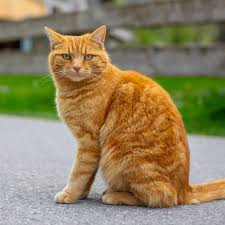


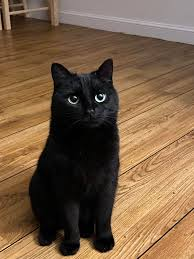


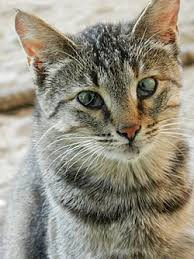


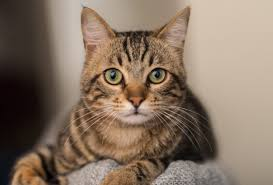


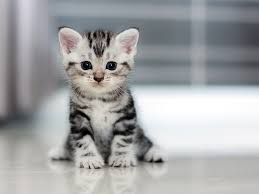




 Query: 'dog'
--------------------------------------------------------------------------------
 Found 3 image(s) for 'dog'

 Could not generate description: name 'description_chain' is not defined




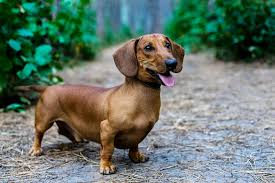


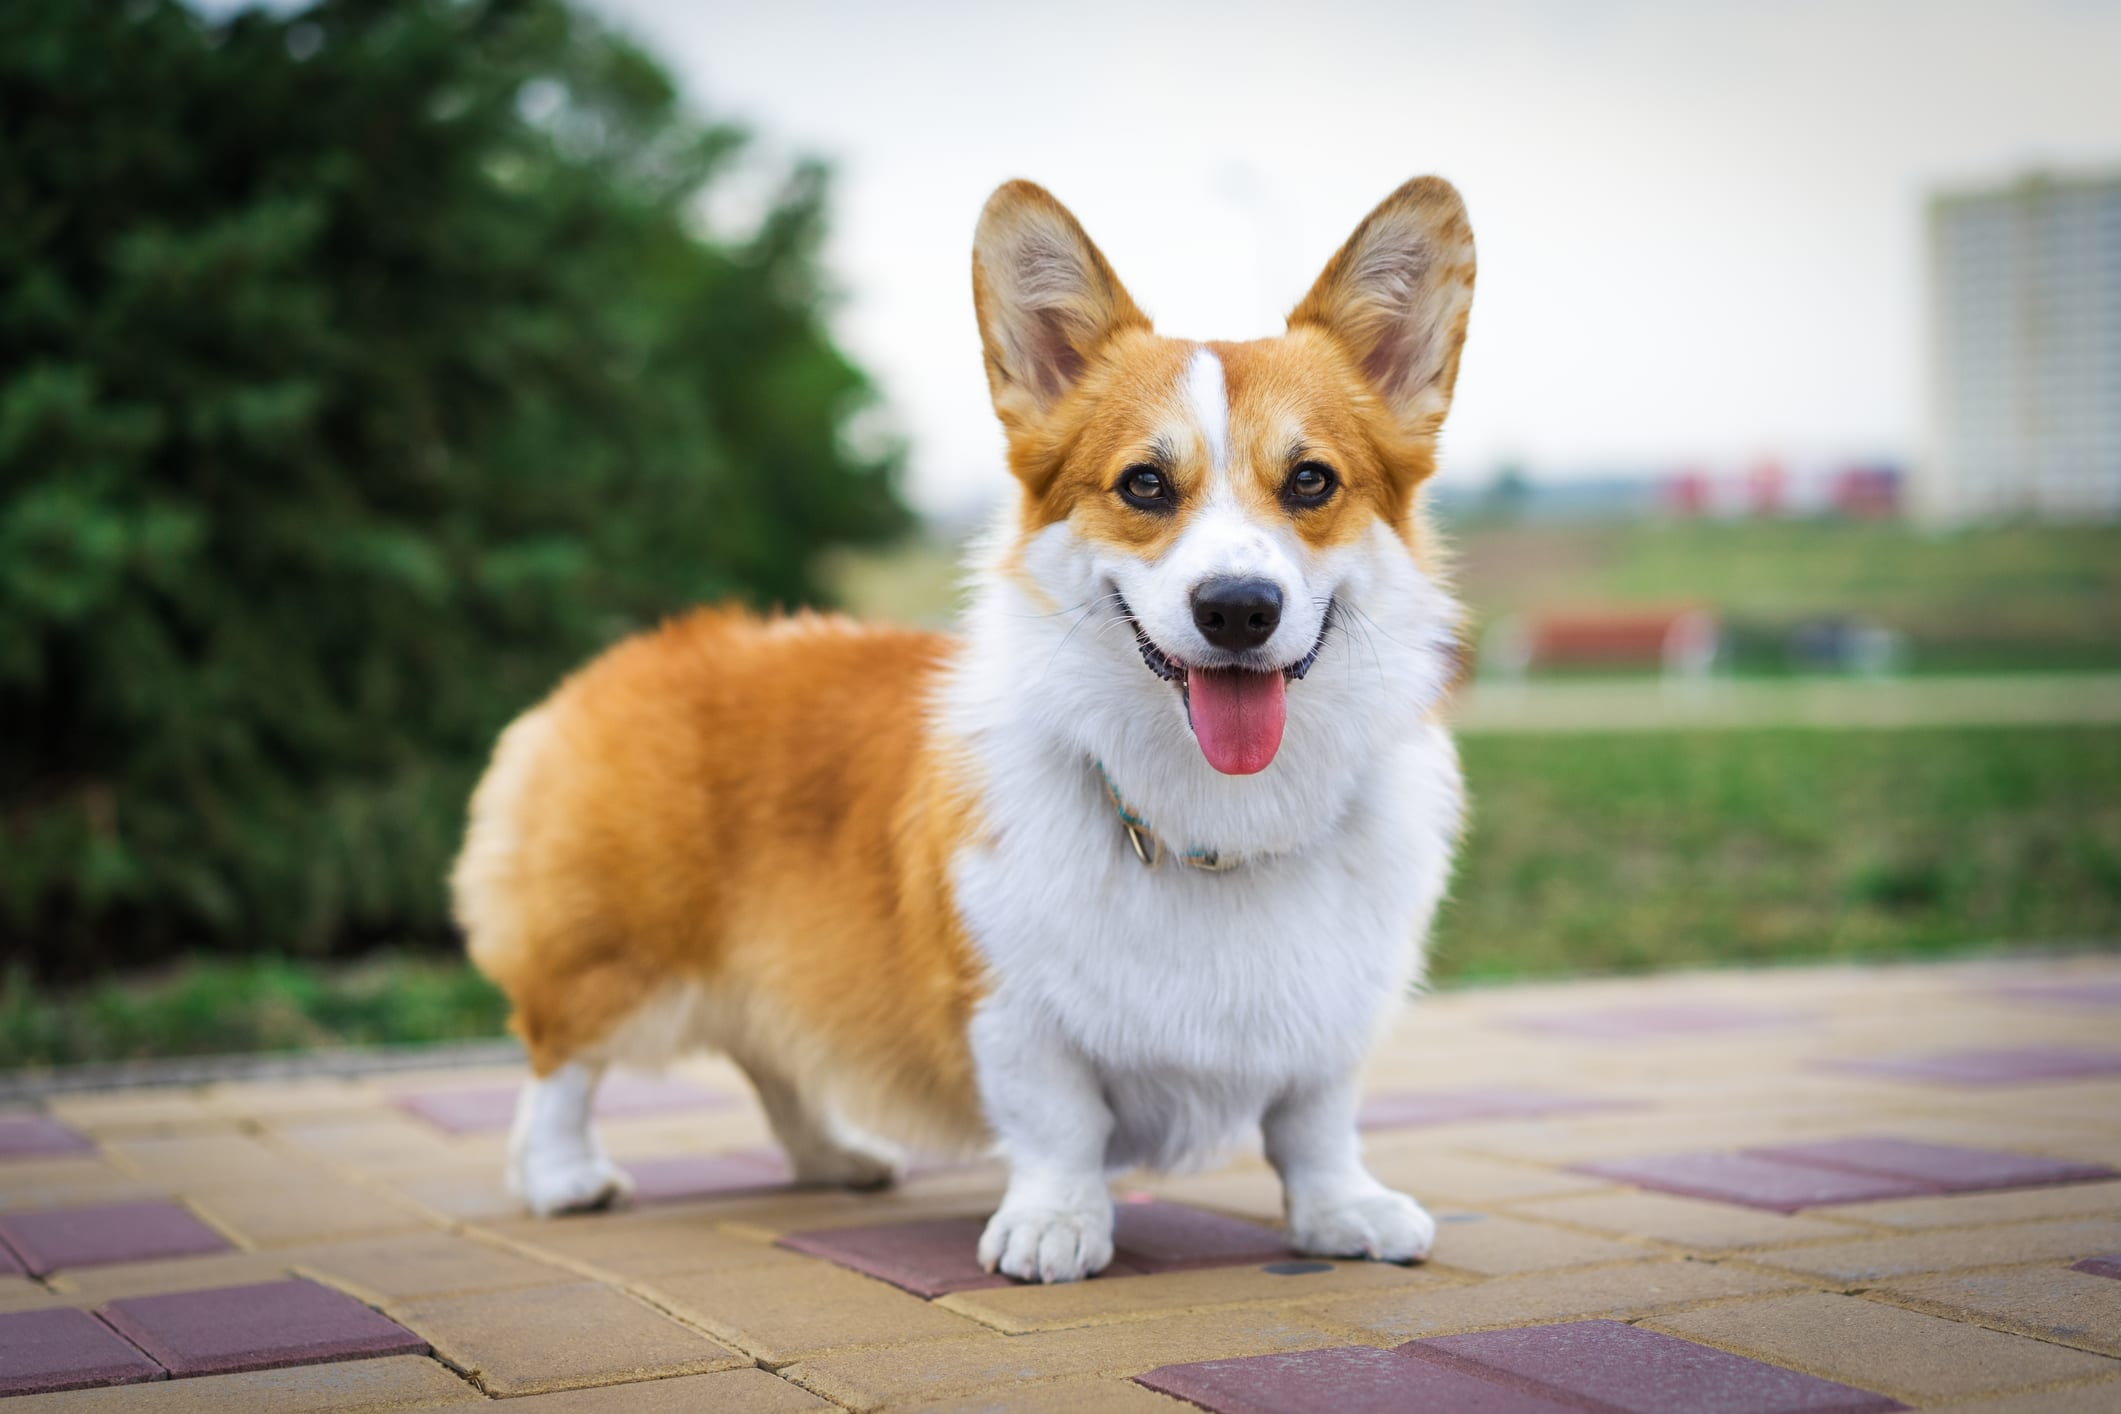


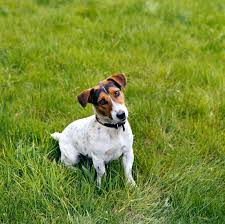

In [ ]:
# Test the chatbot with different queries

print(" IMAGE CHATBOT - TEST MODE")
print("="*80)
print("\nTesting with sample queries...\n")

# Test 1
print(" Query: 'cat'")
print("-"*80)
search_and_display_images("cat")

print("\n\n")

# Test 2
print(" Query: 'dog'")
print("-"*80)
search_and_display_images("dog")

 IMAGE CHATBOT - INTERACTIVE MODE
 Available categories: cat, dog, elephant, leopard, lion, panther, tiger
 Type an animal name to see images and description
 Type 'quit' or 'exit' to stop


 Found 5 image(s) for 'cat'

 Could not generate description: name 'description_chain' is not defined




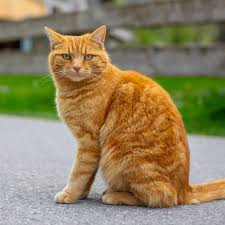


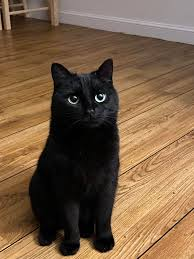


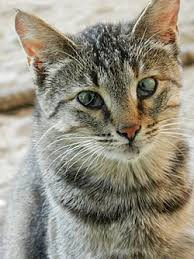


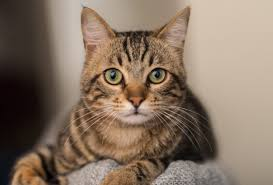


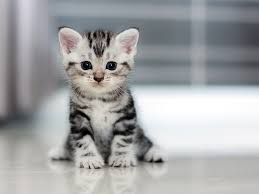



 Found 3 image(s) for 'dog'

 Could not generate description: name 'description_chain' is not defined




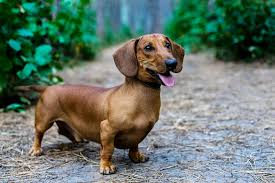


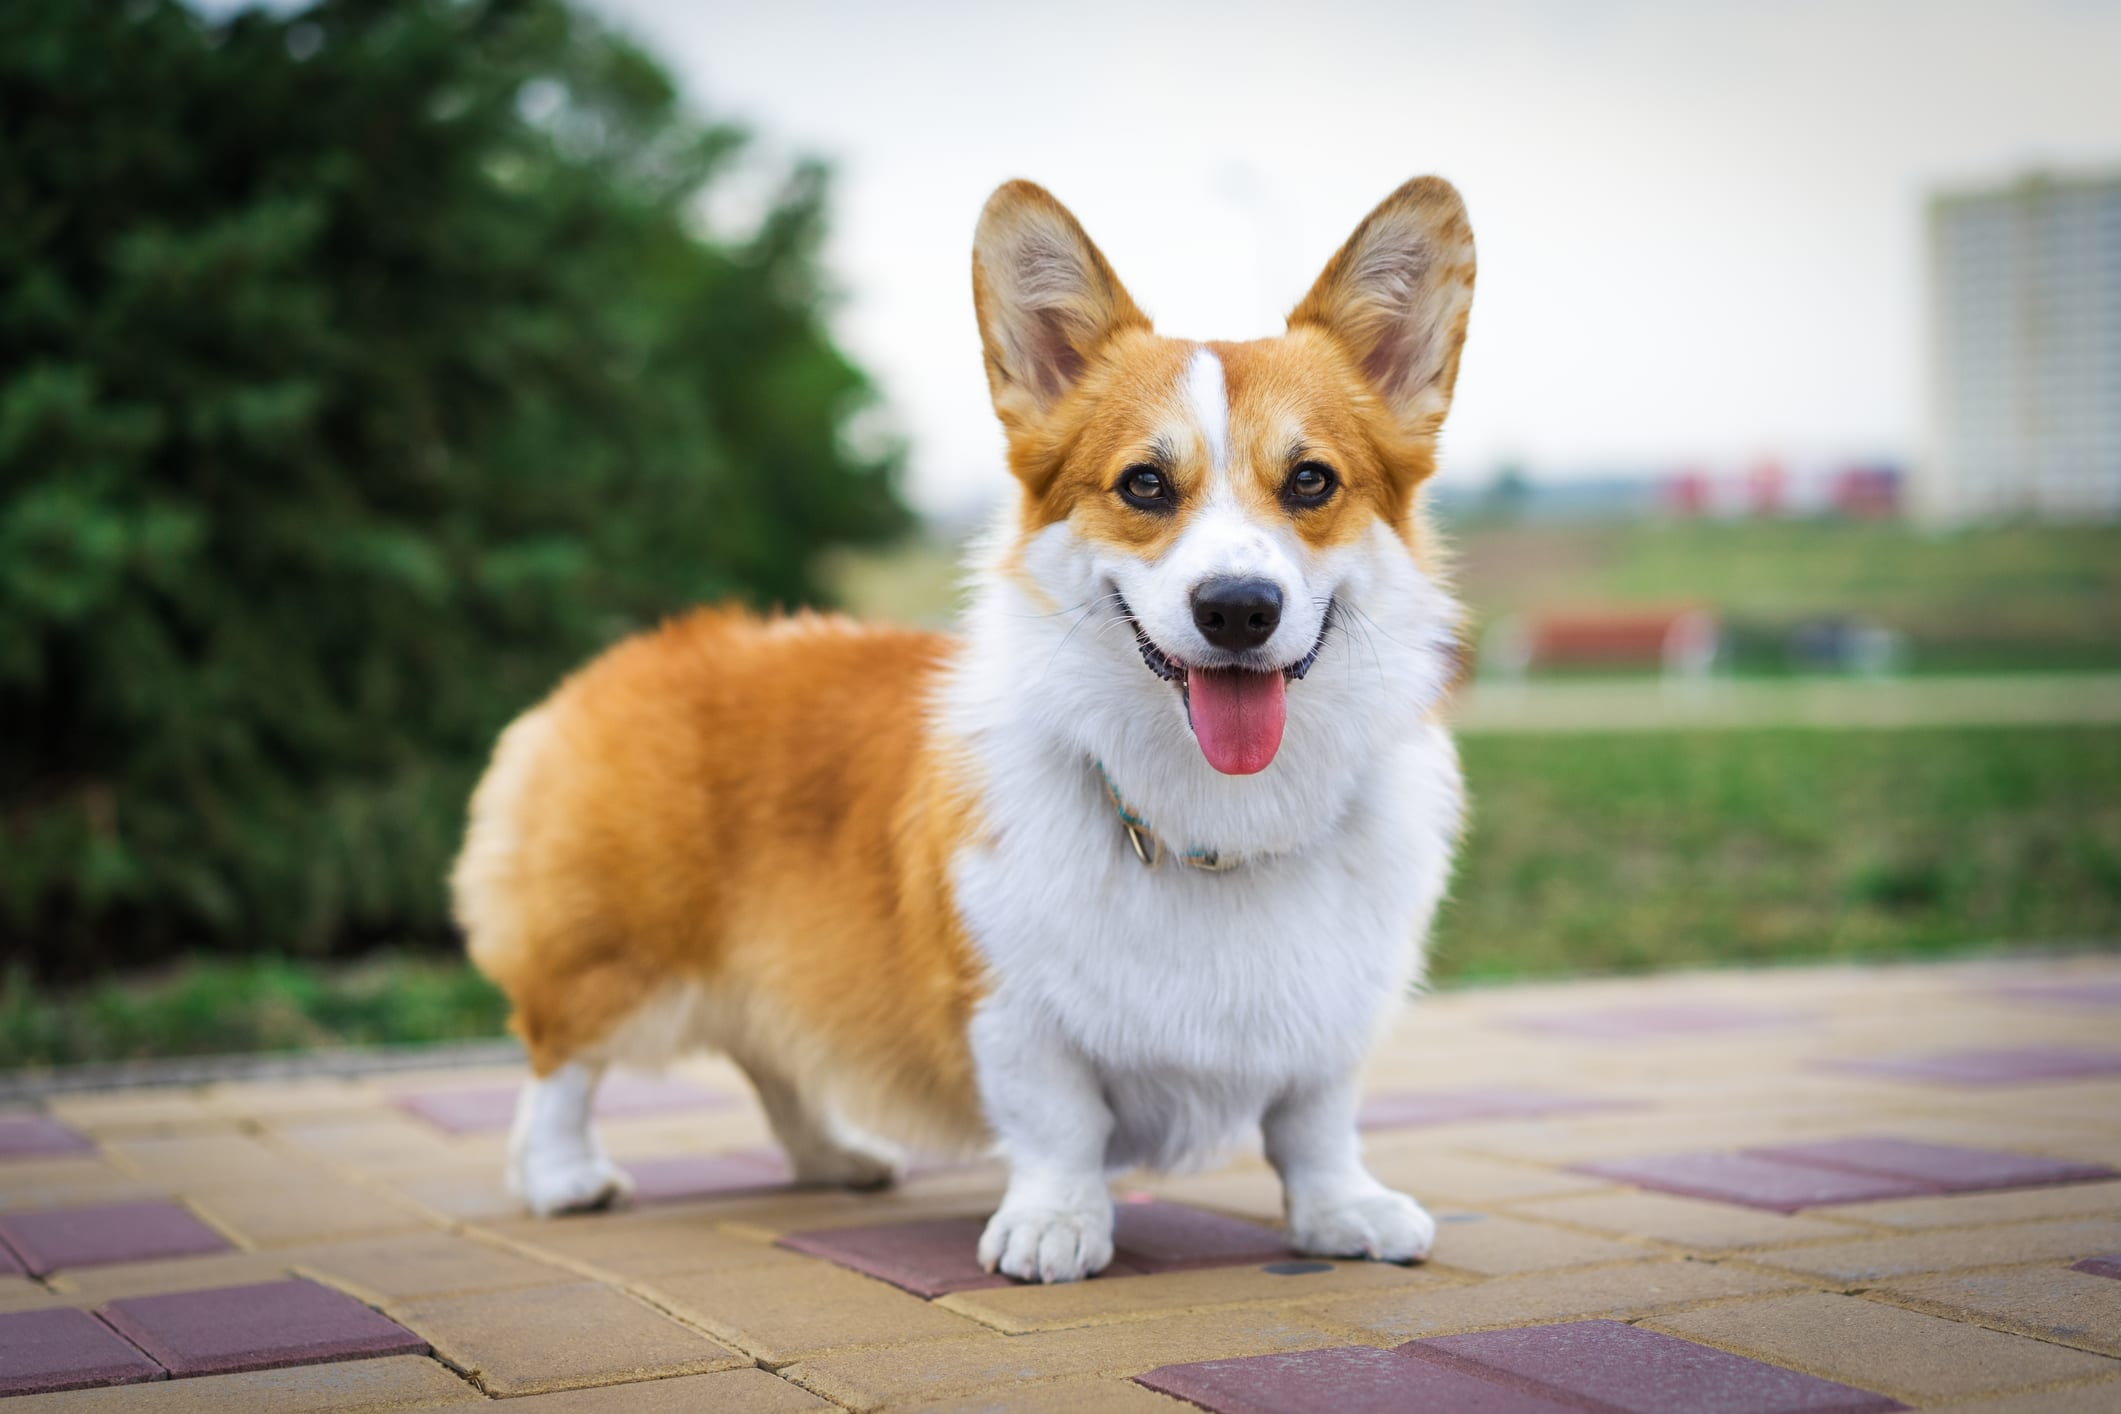


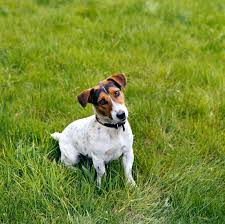

In [ ]:
print(" IMAGE CHATBOT - INTERACTIVE MODE")
print("="*80)
print(f" Available categories: {', '.join(sorted(categories))}")
print(" Type an animal name to see images and description")
print(" Type 'quit' or 'exit' to stop\n")

while True:
    # Get user input
    user_query = input(" Your query: ").strip()

    # Check for exit
    if user_query.lower() in ['quit', 'exit', 'stop', 'bye']:
        print("\n Thanks for using the Image Chatbot! Goodbye!")
        break

    # Check for empty input
    if not user_query:
        print(" Please enter a valid query\n")
        continue

    # Search and display
    print("\n" + "="*80)
    search_and_display_images(user_query)
    print("="*80 + "\n")

 Advanced search function created!

 Try these commands:
   • 'cat dog lion' - Search multiple animals
   • 'all' - Show all images by category

 Example:
 Searching for: cat


 Results for: CAT
 Found 5 image(s) for 'cat'

 Could not generate description: name 'description_chain' is not defined




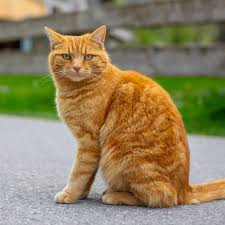


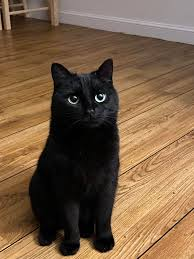


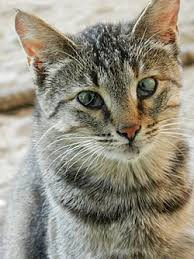


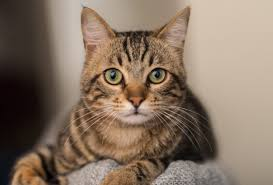


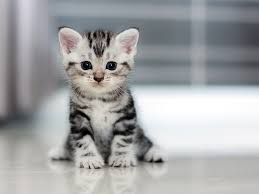

In [ ]:
def advanced_search(query):
    """
    Search with multiple keywords or show all images
    """
    query_lower = query.lower().strip()

    # Special command: show all
    if query_lower in ['all', 'show all', 'everything']:
        print(f" Showing all {len(image_database)} images\n")
        for category in sorted(categories):
            print(f"\n{'='*80}")
            print(f"  Category: {category.upper()}")
            print('='*80)
            search_and_display_images(category)
        return

    # Split query by common separators
    keywords = [kw.strip() for kw in query_lower.replace(',', ' ').replace('and', ' ').split() if kw.strip()]

    if not keywords:
        print("  Please enter valid search terms")
        return

    print(f" Searching for: {', '.join(keywords)}\n")

    # Search for each keyword
    for keyword in keywords:
        if keyword in ['or', 'and', 'the', 'a']:  # Skip common words
            continue
        print(f"\n{'='*80}")
        print(f" Results for: {keyword.upper()}")
        print('='*80)
        search_and_display_images(keyword)

# Test advanced search
print(" Advanced search function created!")
print("\n Try these commands:")
print("   • 'cat dog lion' - Search multiple animals")
print("   • 'all' - Show all images by category")
print("\n Example:")
advanced_search("cat")

In [ ]:
def show_statistics():
    """
    Display detailed statistics about the image database
    """
    print(" IMAGE DATABASE STATISTICS")
    print("="*80 + "\n")

    # Total images
    print(f" Total Images: {len(image_database)}")

    # Images per category
    category_counts = {}
    for data in image_database.values():
        cat = data['category']
        category_counts[cat] = category_counts.get(cat, 0) + 1

    print(f"\n  Categories ({len(category_counts)}):")
    for cat, count in sorted(category_counts.items()):
        bar = "█" * count
        print(f"   {cat.title():15} : {bar} ({count})")

    # Format distribution
    format_counts = {}
    for data in image_database.values():
        fmt = data['format']
        format_counts[fmt] = format_counts.get(fmt, 0) + 1

    print(f"\n  Image Formats:")
    for fmt, count in sorted(format_counts.items()):
        print(f"   {fmt:10} : {count} images")

    # Average dimensions
    total_width = sum(data['width'] for data in image_database.values())
    total_height = sum(data['height'] for data in image_database.values())
    avg_width = total_width // len(image_database)
    avg_height = total_height // len(image_database)

    print(f"\n Average Dimensions: {avg_width}x{avg_height} pixels")

    # Largest and smallest images
    largest = max(image_database.values(), key=lambda x: x['width'] * x['height'])
    smallest = min(image_database.values(), key=lambda x: x['width'] * x['height'])

    print(f"\n Largest Image: {largest['filename']} ({largest['width']}x{largest['height']})")
    print(f" Smallest Image: {smallest['filename']} ({smallest['width']}x{smallest['height']})")

    print("\n" + "="*80)

# Show statistics
show_statistics()

 IMAGE DATABASE STATISTICS

 Total Images: 13

  Categories (7):
   Cat             : █████ (5)
   Dog             : ███ (3)
   Elephant        : █ (1)
   Leopard         : █ (1)
   Lion            : █ (1)
   Panther         : █ (1)
   Tiger           : █ (1)

  Image Formats:
   JPEG       : 13 images

 Average Dimensions: 509x369 pixels

 Largest Image: dog103.jpg (2121x1414)
 Smallest Image: cat105.jpeg (194x259)

